<a href="https://colab.research.google.com/github/Ray-off/TabNet_Marged_data/blob/main/TabNet_Marged_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 from google.colab import files
uploaded = files.upload()

Saving heart_statlog_cleveland_hungary_final (2).csv to heart_statlog_cleveland_hungary_final (2).csv


In [ ]:
import pandas as pd

df = pd.read_csv("heart_statlog_cleveland_hungary_final (2).csv")
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [ ]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.9 MB/s eta 0:00:00


In [ ]:
import os, random, math, json
import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterSampler
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score, confusion_matrix
from pytorch_tabnet.tab_model import TabNetClassifier


In [ ]:
df.columns = (
    df.columns
      .str.strip()
      .str.replace(r"[^\w\s]", "", regex=True)
      .str.replace(r"\s+", "_", regex=True)
      .str.lower()
)

# sanity check
print(df.shape)
df.head(3)

(1190, 12)


,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0


In [ ]:
TARGET = "target"  # detected in your file
assert TARGET in df.columns, f"Target '{TARGET}' not found. Available: {df.columns.tolist()}"

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int).values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (952, 11)  Test: (238, 11)


In [ ]:
# Heuristic for categorical columns: integer dtype & low cardinality (<=10)
cat_cols = [
    c for c in X_train.columns
    if pd.api.types.is_integer_dtype(X_train[c]) and X_train[c].nunique() <= 10
]
# (This will usually catch: sex, chest_pain_type, fasting_blood_sugar, resting_ecg, exercise_angina, st_slope)
cont_cols = [c for c in X_train.columns if c not in cat_cols]

print("Categorical:", cat_cols)
print("Continuous :", cont_cols)

Categorical: ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'resting_ecg', 'exercise_angina', 'st_slope']
Continuous : ['age', 'resting_bp_s', 'cholesterol', 'max_heart_rate', 'oldpeak']


In [ ]:
# Fit encoders only on TRAIN to avoid leakage
oe = OrdinalEncoder(dtype=np.int64)  # maps to 0..K-1
scaler = StandardScaler()

Xtr = X_train.copy()
Xte = X_test.copy()

if cat_cols:
    Xtr[cat_cols] = oe.fit_transform(Xtr[cat_cols])
    Xte[cat_cols] = oe.transform(Xte[cat_cols])

if cont_cols:
    Xtr[cont_cols] = scaler.fit_transform(Xtr[cont_cols])
    Xte[cont_cols] = scaler.transform(Xte[cont_cols])

In [ ]:
# TabNet needs categorical metadata
feature_names = Xtr.columns.tolist()
cat_idxs = [feature_names.index(c) for c in cat_cols]
cat_dims = [int(Xtr[c].nunique()) for c in cat_cols]

Xtr_np = Xtr.values
Xte_np = Xte.values

print("cat_idxs:", cat_idxs)
print("cat_dims:", cat_dims)

cat_idxs: [1, 2, 5, 6, 8, 10]
cat_dims: [2, 4, 2, 3, 2, 4]


In [ ]:
device_name = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device_name)

baseline_params = dict(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5, lambda_sparse=1e-4,
    momentum=0.3,  # batch norm momentum
    cat_idxs=cat_idxs, cat_dims=cat_dims, cat_emb_dim=2,  # small embeddings
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-3),
    mask_type='sparsemax',
    device_name=device_name,
    verbose=0
)

clf = TabNetClassifier(**baseline_params)

clf.fit(
    X_train=Xtr_np, y_train=y_train,
    eval_set=[(Xtr_np, y_train), (Xte_np, y_test)],
    eval_name=['train','valid'],
    eval_metric=['auc'],
    max_epochs=200,
    patience=40,
    batch_size=256,
    virtual_batch_size=32,
)

proba = clf.predict_proba(Xte_np)[:,1]
pred  = (proba >= 0.5).astype(int)

print("Baseline Accuracy:", accuracy_score(y_test, pred))
print("Baseline ROC-AUC:", roc_auc_score(y_test, proba))
print("Baseline F1     :", f1_score(y_test, pred))
print(classification_report(y_test, pred, digits=4))


Device: cuda

Early stopping occurred at epoch 190 with best_epoch = 150 and best_valid_auc = 0.94777
Baseline Accuracy: 0.8781512605042017
Baseline ROC-AUC: 0.9477749433106577
Baseline F1     : 0.888030888030888
              precision    recall  f1-score   support

           0     0.8952    0.8393    0.8664       112
           1     0.8647    0.9127    0.8880       126

    accuracy                         0.8782       238
   macro avg     0.8799    0.8760    0.8772       238
weighted avg     0.8791    0.8782    0.8778       238



/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
def cv_auc_for_params(params, X, y, n_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    aucs = []

    for tr_idx, va_idx in skf.split(X, y):
        Xtr_f, Xva_f = X[tr_idx], X[va_idx]
        ytr_f, yva_f = y[tr_idx], y[va_idx]

        clf = TabNetClassifier(
            cat_idxs=cat_idxs, cat_dims=cat_dims,
            device_name=device_name, verbose=0,
            **{k: v for k, v in params.items() if k not in ["batch_size", "virtual_batch_size"]}
        )

        clf.fit(
            X_train=Xtr_f, y_train=ytr_f,
            eval_set=[(Xva_f, yva_f)],
            eval_metric=['auc'],
            max_epochs=200, patience=40,
            batch_size=params.get('batch_size', 256),
            virtual_batch_size=params.get('virtual_batch_size', 32),
        )
        proba = clf.predict_proba(Xva_f)[:,1]
        aucs.append(roc_auc_score(yva_f, proba))

        # free memory between folds
        del clf
        torch.cuda.empty_cache() if device_name=='cuda' else None

    return float(np.mean(aucs))

param_grid = {
    "n_d":          [16, 24, 32, 48, 64],
    "n_a":          [16, 24, 32, 48, 64],
    "n_steps":      [4, 5, 6, 7, 8],
    "gamma":        [1.0, 1.2, 1.5, 1.7, 2.0],
    "lambda_sparse":[1e-5, 1e-4, 5e-4, 1e-3],
    "momentum":     [0.02, 0.1, 0.2, 0.3],
    "mask_type":    ["entmax", "sparsemax"],
    "cat_emb_dim":  [2, 3, 4, 5],
    "optimizer_fn": [torch.optim.Adam],
    "optimizer_params": [dict(lr=lr) for lr in [1e-3, 2e-3, 5e-3, 1e-2]],
    "batch_size":   [128, 256, 512],
    "virtual_batch_size":[16, 32, 64],
}

n_iter = 18  # you can raise to 30–50 if you want even better results
sampler = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=42))

best_auc, best_params = -1.0, None
for i, params in enumerate(sampler, 1):
    auc = cv_auc_for_params(params, Xtr_np, y_train, n_splits=5, seed=42)
    print(f"[{i:02d}/{n_iter}] AUC={auc:.4f}  params={params}")
    if auc > best_auc:
        best_auc, best_params = auc, params

print("\nBest CV AUC:", best_auc)
print("Best params:", json.dumps({k: (str(v) if callable(v) else v) for k,v in best_params.items()}, indent=2))



Early stopping occurred at epoch 158 with best_epoch = 118 and best_val_0_auc = 0.89593


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 147 with best_epoch = 107 and best_val_0_auc = 0.9549


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 168 with best_epoch = 128 and best_val_0_auc = 0.91601


...

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 131 with best_epoch = 91 and best_val_0_auc = 0.91744


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



Early stopping occurred at epoch 127 with best_epoch = 87 and best_val_0_auc = 0.89822
[18/18] AUC=0.8908  params={'virtual_batch_size': 32, 'optimizer_params': {'lr': 0.005}, 'optimizer_fn': <class 'torch.optim.adam.Adam'>, 'n_steps': 8, 'n_d': 16, 'n_a': 48, 'momentum': 0.1, 'mask_type': 'entmax', 'lambda_sparse': 0.0005, 'gamma': 1.7, 'cat_emb_dim': 3, 'batch_size': 256}

Best CV AUC: 0.9466548361577731
Best params: {
  "virtual_batch_size": 32,
  "optimizer_params": {
    "lr": 0.005
  },
  "optimizer_fn": "<class 'torch.optim.adam.Adam'>",
  "n_steps": 4,
  "n_d": 24,
  "n_a": 32,
  "momentum": 0.1,
  "mask_type": "entmax",
  "lambda_sparse": 0.001,
  "gamma": 1.0,
  "cat_emb_dim": 3,
  "batch_size": 128
}


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
final_params = {**best_params, "device_name": device_name, "verbose": 0}

# Extract batch_size and virtual_batch_size
batch_size = final_params.pop('batch_size', 256)
virtual_batch_size = final_params.pop('virtual_batch_size', 32)

final_clf = TabNetClassifier(cat_idxs=cat_idxs, cat_dims=cat_dims, **final_params)

final_clf.fit(
    X_train=Xtr_np, y_train=y_train,
    eval_set=[(Xtr_np, y_train), (Xte_np, y_test)],
    eval_name=['train','valid'],
    eval_metric=['auc'],
    max_epochs=300, patience=60,
    batch_size=batch_size,
    virtual_batch_size=virtual_batch_size
)

# Predict probabilities
test_proba = final_clf.predict_proba(Xte_np)[:, 1]

# Optional: tune decision threshold on train for best F1
from sklearn.metrics import precision_recall_curve, accuracy_score, roc_auc_score, f1_score, classification_report, confusion_matrix
import numpy as np

p, r, thr = precision_recall_curve(y_train, final_clf.predict_proba(Xtr_np)[:, 1])
f1s = 2*p*r/(p+r+1e-12)
best_thr = max(zip(f1s, np.r_[thr, 1.0]))[1]

test_pred = (test_proba >= best_thr).astype(int)

print(f"Threshold used: {best_thr:.3f}")
print("Test Accuracy:", accuracy_score(y_test, test_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, test_proba))
print("Test F1     :", f1_score(y_test, test_pred))
print(classification_report(y_test, test_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, test_pred))



Early stopping occurred at epoch 176 with best_epoch = 116 and best_valid_auc = 0.95493


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Threshold used: 0.401
Test Accuracy: 0.9033613445378151
Test ROC-AUC: 0.9549319727891156
Test F1     : 0.9068825910931174
              precision    recall  f1-score   support

           0     0.8803    0.9196    0.8996       112
           1     0.9256    0.8889    0.9069       126

    accuracy                         0.9034       238
   macro avg     0.9030    0.9043    0.9032       238
weighted avg     0.9043    0.9034    0.9034       238

Confusion matrix:
 [[103   9]
 [ 14 112]]


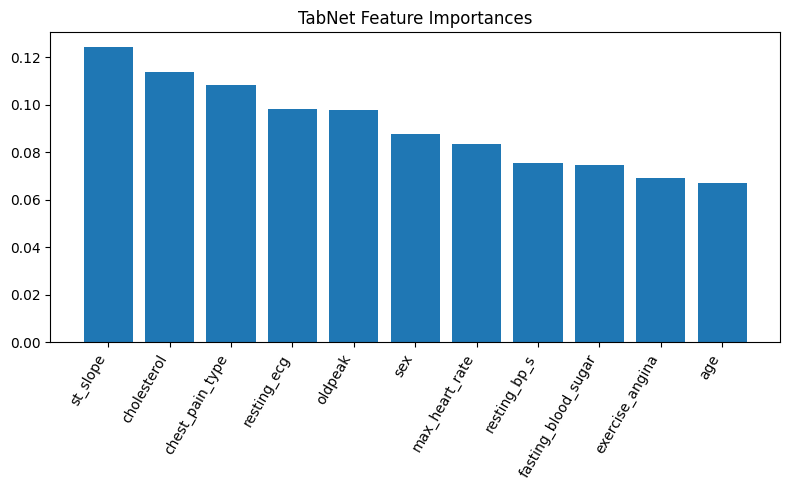

In [ ]:
import matplotlib.pyplot as plt
imp = final_clf.feature_importances_
order = np.argsort(imp)[::-1]
plt.figure(figsize=(8,5))
plt.bar(range(len(imp)), imp[order])
plt.xticks(range(len(imp)), [feature_names[i] for i in order], rotation=60, ha='right')
plt.title("TabNet Feature Importances")
plt.tight_layout()
plt.show()

# Per-sample explanations (mask)
# mask = final_clf.explain(Xte_np)   # returns list of masks per step
# mask[0].shape  # (n_samples, n_features)
